In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.max_rows = 1000

In [91]:
df = pd.read_csv("/Users/irsyad/Desktop/Portfolio/credit-risk-lending-club/data/processed/accepted_features.csv", low_memory = False)

df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['vintage'] = df['issue_d'].dt.to_period('M')

In [92]:
df.columns.to_list()

['id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'policy_code',
 'application_type',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths

In [93]:
vintage_summary = df.groupby("vintage",as_index=False).agg(
    total_loans = pd.NamedAgg(column="is_default",aggfunc="count"),
    total_defaults = pd.NamedAgg(column="is_default",aggfunc="sum")
)

In [94]:
vintage_summary['default_rate'] = (vintage_summary["total_defaults"]/vintage_summary["total_loans"]*100).round(2)

print(vintage_summary.head())

   vintage  total_loans  total_defaults  default_rate
0  2007-07            2               0          0.00
1  2007-08            6               1         16.67
2  2007-09            3               0          0.00
3  2007-10            5               0          0.00
4  2007-11            8               0          0.00


In [95]:
vintage_summary["vintage"] = vintage_summary["vintage"].dt.to_timestamp()

In [103]:
years_to_plot = [2011,2012,2013,2014,2015,2016]

vintage_subsets = {}
for year in years_to_plot:
    subset = vintage_summary[vintage_summary["vintage"].dt.year == year].copy()
    subset["month"] = subset["vintage"].dt.strftime("%b")
    vintage_subsets[year] = subset

Saved successfully!


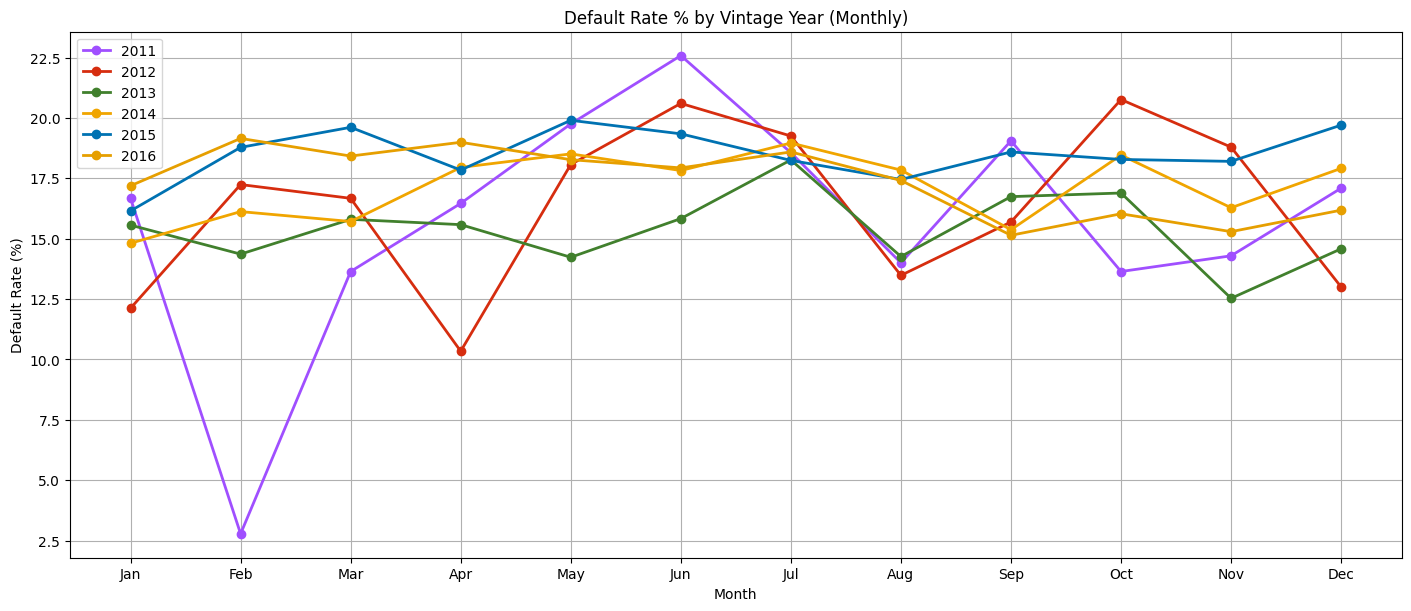

In [110]:
colors = ["#A04FFF", "#D62D0F", "#41802D", "#F0A500", "#0072B2", "#E69F00"]

fig, ax = plt.subplots(figsize=(14, 6), layout="constrained")

for i, year in enumerate(years_to_plot):
    subset = vintage_subsets[year]
    ax.plot("month", "default_rate", data=subset,
            color=colors[i], linewidth=2, marker="o",
            markersize=6, label=str(year))

#other artists
ax.set_title("Default Rate % by Vintage Year (Monthly)")
ax.set_xlabel("Month")
ax.set_ylabel("Default Rate (%)")
ax.legend()
ax.grid(True)

plt.savefig("/Users/irsyad/Desktop/Portfolio/credit-risk-lending-club/outputs/vintage_default_rate_by_year.png",transparent=False,dpi=250)
print("Saved successfully!")
plt.show()

In [114]:
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], errors='coerce')

In [148]:
defaults_df = df[df['is_default'] == 1].copy()
print(f"Total defaults: {len(defaults_df)}")

Total defaults: 14946


In [149]:
print(defaults_df[['issue_d', 'last_pymnt_d']].dtypes)
print(defaults_df[['issue_d', 'last_pymnt_d']].head(5))

issue_d         datetime64[us]
last_pymnt_d    datetime64[us]
dtype: object
     issue_d last_pymnt_d
2 2015-12-01   2017-11-01
3 2015-12-01   2016-07-01
4 2015-12-01   2018-08-01
5 2015-12-01   2016-10-01
9 2015-12-01   2019-03-01


In [150]:
print(defaults_df[['issue_d', 'last_pymnt_d']].isnull().sum())

issue_d           0
last_pymnt_d    112
dtype: int64


In [151]:
defaults_df = defaults_df.dropna(subset=['last_pymnt_d'])
print(f"Defaults after dropping null last_pymnt_d: {len(defaults_df)}")

Defaults after dropping null last_pymnt_d: 14834


In [152]:
defaults_df['loan_age_months'] = (
    defaults_df['last_pymnt_d'].dt.to_period('M') - 
    defaults_df['issue_d'].dt.to_period('M')
).apply(lambda x: x.n if pd.notna(x) else pd.NA)

print(defaults_df['loan_age_months'].describe())

count    14834.000000
mean        16.511595
std         10.167095
min          1.000000
25%          9.000000
50%         15.000000
75%         23.000000
max         61.000000
Name: loan_age_months, dtype: float64


In [153]:
defaults_df['vintage_year'] = defaults_df['issue_d'].dt.year

print(defaults_df[['issue_d', 'last_pymnt_d', 'loan_age_months', 'vintage_year']].head(10))

      issue_d last_pymnt_d  loan_age_months  vintage_year
2  2015-12-01   2017-11-01               23          2015
3  2015-12-01   2016-07-01                7          2015
4  2015-12-01   2018-08-01               32          2015
5  2015-12-01   2016-10-01               10          2015
9  2015-12-01   2019-03-01               39          2015
15 2015-12-01   2018-01-01               25          2015
39 2015-12-01   2017-05-01               17          2015
49 2015-12-01   2016-09-01                9          2015
55 2015-12-01   2017-01-01               13          2015
67 2015-12-01   2017-09-01               21          2015


In [154]:
defaults_by_age = defaults_df.groupby(
    ['vintage_year', 'loan_age_months'],as_index = False
)['is_default'].count()

defaults_by_age.columns = ['vintage_year', 'loan_age_months', 'new_defaults']

print(defaults_by_age.head(10))

   vintage_year  loan_age_months  new_defaults
0          2007               10             1
1          2007               21             1
2          2008                1             1
3          2008                4             2
4          2008                5             1
5          2008               10             1
6          2008               11             1
7          2008               12             1
8          2008               14             1
9          2008               16             1


In [155]:
total_by_vintage = df.groupby(
    df['issue_d'].dt.year
)['is_default'].count().reset_index()

total_by_vintage.columns = ['vintage_year', 'total_loans']

print(total_by_vintage)

    vintage_year  total_loans
0           2007           31
1           2008          110
2           2009          253
3           2010          640
4           2011         1092
5           2012         2640
6           2013         6759
7           2014        11651
8           2015        21107
9           2016        21787
10          2017        22107
11          2018        25067


In [156]:
defaults_by_age = defaults_by_age.merge(total_by_vintage, on='vintage_year')
print(defaults_by_age.head(10))

   vintage_year  loan_age_months  new_defaults  total_loans
0          2007               10             1           31
1          2007               21             1           31
2          2008                1             1          110
3          2008                4             2          110
4          2008                5             1          110
5          2008               10             1          110
6          2008               11             1          110
7          2008               12             1          110
8          2008               14             1          110
9          2008               16             1          110


In [158]:
defaults_by_age = defaults_by_age.sort_values(['vintage_year', 'loan_age_months'])

defaults_by_age['cumulative_defaults'] = defaults_by_age.groupby(
    'vintage_year'
)['new_defaults'].cumsum()

defaults_by_age['cumulative_default_rate'] = (
    defaults_by_age['cumulative_defaults'] / defaults_by_age['total_loans'] * 100
).round(2)

print(defaults_by_age.head(10))

   vintage_year  loan_age_months  new_defaults  total_loans  \
0          2007               10             1           31   
1          2007               21             1           31   
2          2008                1             1          110   
3          2008                4             2          110   
4          2008                5             1          110   
5          2008               10             1          110   
6          2008               11             1          110   
7          2008               12             1          110   
8          2008               14             1          110   
9          2008               16             1          110   

   cumulative_defaults  cumulative_default_rate  
0                    1                     3.23  
1                    2                     6.45  
2                    1                     0.91  
3                    3                     2.73  
4                    4                     3.64  
5     

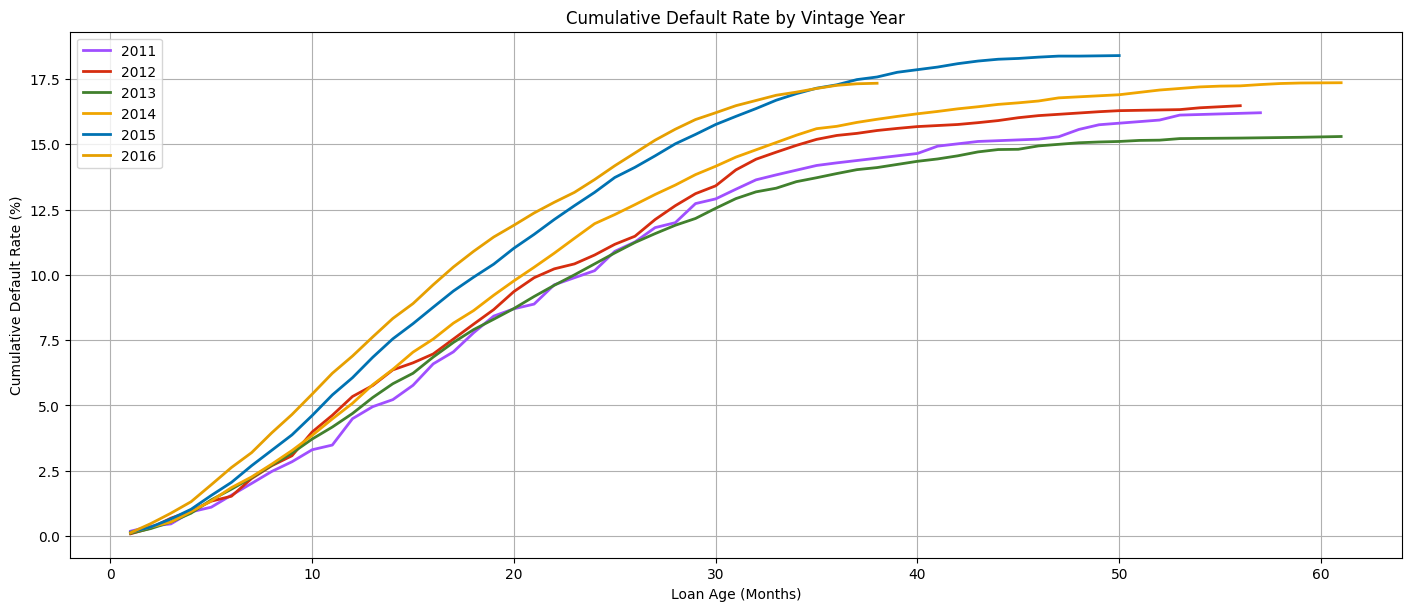

In [159]:
years_to_plot = [2011, 2012, 2013, 2014, 2015, 2016]
colors = ["#A04FFF", "#D62D0F", "#41802D", "#F0A500", "#0072B2", "#E69F00"]

fig, ax = plt.subplots(figsize=(14, 6), layout="constrained")

for i, year in enumerate(years_to_plot):
    subset = defaults_by_age[defaults_by_age['vintage_year'] == year]
    ax.plot('loan_age_months', 'cumulative_default_rate',
            data=subset,
            color=colors[i],
            linewidth=2,
            label=str(year))

ax.set_title("Cumulative Default Rate by Vintage Year")
ax.set_xlabel("Loan Age (Months)")
ax.set_ylabel("Cumulative Default Rate (%)")
ax.legend()
ax.grid(True)

plt.savefig('../outputs/cumulative_vintage_curves.png', dpi=250)
plt.show()